
Sample data:
   machine_age  annual_usage customer_size  contract_duration  \
0            7   1996.399977         Small                  2   
1            4   2307.515097         Large                  1   
2           13    549.238159         Small                  3   
3           11   3000.183756         Large                  5   
4            8   1634.463082        Medium                  2   

   previous_failures  discount  accepted  
0                  2         0         1  
1                  3         0         1  
2                  1         1         0  
3                  2         0         1  
4                  3         0         0  

Baseline model AUC:
0.666

Average estimated treatment effect:
0.1075

Estimated uplift by customer segment:
customer_size
Small     0.150822
Medium    0.065448
Large     0.061863
Name: estimated_uplift, dtype: float64

Top 10 customers most responsive to discount:
      machine_age  annual_usage  contract_duration  previous_failures 

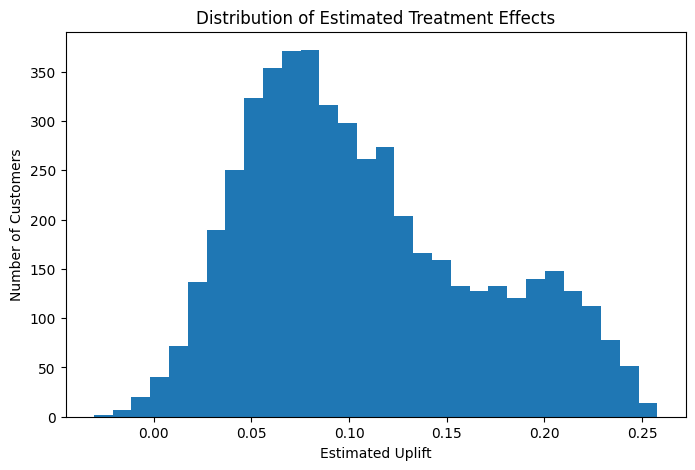

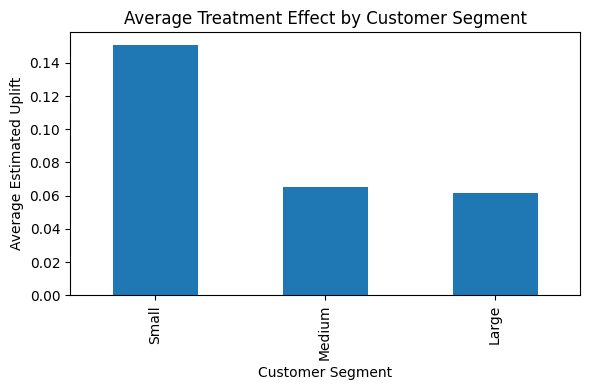


Dataset saved successfully.


In [ ]:
# ============================================================
# Estimating Customer Acceptance Under Alternative Pricing Strategies
# Synthetic Uplift Modelling Study
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# ============================================================
# 1. Generate synthetic customers
# ============================================================

N = 5000

machine_age = np.random.randint(1, 15, N)

annual_usage = np.random.normal(
    loc=2000,
    scale=500,
    size=N
)
annual_usage = np.clip(annual_usage, 500, None)

customer_size = np.random.choice(
    ["Small", "Medium", "Large"],
    size=N,
    p=[0.5, 0.3, 0.2]
)

contract_duration = np.random.choice(
    [1, 2, 3, 5],
    size=N,
    p=[0.2, 0.3, 0.3, 0.2]
)

previous_failures = np.random.poisson(
    lam=2,
    size=N
)

# ============================================================
# 2. Treatment assignment
# ============================================================

discount = np.random.binomial(
    n=1,
    p=0.5,
    size=N
)

# ============================================================
# 3. Simulate customer behaviour
# ============================================================

# Base willingness to purchase (without discount)

size_effect = np.select(
    [
        customer_size == "Small",
        customer_size == "Medium",
        customer_size == "Large"
    ],
    [
        0.0,
        0.4,
        0.8
    ]
)

baseline_logit = (
    -1.4
    + 0.07 * machine_age
    + 0.00035 * annual_usage
    + 0.20 * previous_failures
    + 0.12 * contract_duration
    + size_effect
)

# Heterogeneous treatment effect

base_discount = np.select(
    [
        customer_size == "Small",
        customer_size == "Medium",
        customer_size == "Large"
    ],
    [
        0.70,
        0.45,
        0.25
    ]
)

discount_effect = (
    base_discount
    + 0.05 * previous_failures
    + 0.03 * contract_duration
    - 0.00005 * annual_usage
    + np.random.normal(0, 0.12, N)
)

# Prevent unrealistically extreme treatment effects

discount_effect = np.clip(
    discount_effect,
    0.0,
    1.0
)

logit = baseline_logit + discount * discount_effect

prob_accept = 1 / (1 + np.exp(-logit))

accepted = np.random.binomial(
    n=1,
    p=prob_accept
)

# ============================================================
# 4. Create dataframe
# ============================================================

df = pd.DataFrame({
    "machine_age": machine_age,
    "annual_usage": annual_usage,
    "customer_size": customer_size,
    "contract_duration": contract_duration,
    "previous_failures": previous_failures,
    "discount": discount,
    "accepted": accepted
})

print("\nSample data:")
print(df.head())

# ============================================================
# 5. Prepare data
# ============================================================

data = pd.get_dummies(
    df,
    columns=["customer_size"],
    drop_first=True
)

# ============================================================
# 6. Baseline predictive model
# ============================================================

X = data.drop(columns=["accepted"])
y = data["accepted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

baseline = LogisticRegression(
    max_iter=2000
)

baseline.fit(X_train, y_train)

pred = baseline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, pred)

print("\nBaseline model AUC:")
print(round(auc, 3))

# ============================================================
# 7. T-Learner
# ============================================================

treated = data[data["discount"] == 1]
control = data[data["discount"] == 0]

features = [
    c for c in data.columns
    if c != "accepted"
]

X_treated = treated[features]
y_treated = treated["accepted"]

X_control = control[features]
y_control = control["accepted"]

model_treated = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

model_control = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

model_treated.fit(X_treated, y_treated)
model_control.fit(X_control, y_control)

# ============================================================
# 8. Estimate uplift
# ============================================================

all_X = data[features]

p_treated = model_treated.predict_proba(all_X)[:, 1]
p_control = model_control.predict_proba(all_X)[:, 1]

uplift = p_treated - p_control

data["estimated_uplift"] = uplift
data["customer_size"] = df["customer_size"]

# ============================================================
# 9. Main results
# ============================================================

print("\nAverage estimated treatment effect:")
print(round(data["estimated_uplift"].mean(), 4))

# ============================================================
# 10. Segment analysis
# ============================================================

segment_results = (
    data
    .groupby("customer_size")["estimated_uplift"]
    .mean()
    .sort_values(ascending=False)
)

print("\nEstimated uplift by customer segment:")
print(segment_results)

# ============================================================
# 11. Most responsive customers
# ============================================================

print("\nTop 10 customers most responsive to discount:")

print(
    data[[
        "machine_age",
        "annual_usage",
        "contract_duration",
        "previous_failures",
        "estimated_uplift"
    ]]
    .sort_values(
        "estimated_uplift",
        ascending=False
    )
    .head(10)
)

# ============================================================
# 12. Top uplift segment composition
# ============================================================

top_group = (
    data
    .sort_values(
        "estimated_uplift",
        ascending=False
    )
    .head(500)
)

print("\nCustomer composition among top 500 uplift scores:")

print(
    top_group["customer_size"]
    .value_counts(normalize=True)
)

# ============================================================
# 13. Plot 1 - Uplift distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    data["estimated_uplift"],
    bins=30
)

plt.xlabel("Estimated Uplift")
plt.ylabel("Number of Customers")
plt.title("Distribution of Estimated Treatment Effects")

plt.show()

# ============================================================
# 14. Plot 2 - Segment comparison
# ============================================================

plt.figure(figsize=(6, 4))

segment_results.plot(
    kind="bar"
)

plt.ylabel("Average Estimated Uplift")
plt.xlabel("Customer Segment")
plt.title("Average Treatment Effect by Customer Segment")

plt.tight_layout()

plt.show()

# ============================================================
# 15. Save dataset
# ============================================================

data.to_csv(
    "synthetic_service_contract_data.csv",
    index=False
)

print("\nDataset saved successfully.")